**PHASE 2. FEATURE ENGINEERING**

In the previous phase, we have obtained an AR(1) + GARCH(1,1) + student-t model which was trained purely based on historical return. In this phase, we will aim to use scikit-learn to conduct feature engineering, which involves refining the obtained GARCH model by adding supplementary training references.

**I. Data and resources preparation**

We first fetch the bitcoin data price from Yahoo Finance from 2018. We define two base values of the data: log-difference and GARCH volatility.

1. Log-difference

    This is the data we passed to the ARMA-GARCH model during phase 1. We aim to utilize the log-difference to identify the movement of returns, helping the model to more accurately forecast the conditional volatility of the Bitcoin price.

2. GARCH volatility
    
    This is the conditional volatility (standard deviation which depends on the historic volatility) obtained from ARMA-GARCH model.

In [ ]:
!pip install arch
from arch import arch_model
import yfinance as yf
import numpy as np
btc = yf.download("BTC-USD", start="2018-01-01", interval="1d")
btc = btc[['Close']]
btc.dropna(inplace=True)
log_diff = np.log(btc['Close']).diff()
log_diff.dropna(inplace=True)
res = arch_model(log_diff * 10, vol = "GARCH", mean = "ARX", lags = 1, p = 1, q = 1, dist = 't').fit(disp = 'off') #Multiplication by 10 due to recommended scaling
btc = btc.iloc[1:].copy()  #align with log_diff
btc['log_return'] = log_diff.values
btc['garch_volatility'] = res.conditional_volatility / 10 #Division by 10 to calibrate the scaling

**II. Methodologies**

Features are defined as supplementary informations for the model to obtain more-accurate result by taking account different factors (not only past data). We define several features for the model:

1. Lag return (*return_lag_1, return_lag_2* )

    Lag return is defined as the return on some data point in the past. This will give the model a sense of how return in the past influences current return, which is consistent to identifying autocorrelation within returns.

2. Lag volatility (*garch_vol_lag_1, garch_vol_lag_2, target_volatility* )

    Our goal is to predict the price volatility by capturing the volatility clustering. Similar to lag return, this gives information about the movement of volatility (volatility cluster). This is the primary driver of our model, as we will train our model based on current and previous volatility relationship.

3. Rolling mean (*rolling_mean_7* )

    Rolling mean will give a sense to the model of "*what is happening to the return recently*"; or in other word, it provides contexts about the trend of price return.

In [16]:
btc['return_lag_1'] = btc['log_return'].shift(1) #Yesterday's return
btc['return_lag_2'] = btc['log_return'].shift(2) #Return two days ago
btc['garch_vol_lag_1'] = btc['garch_volatility'].shift(1) #Yesterday's volatility
btc['garch_vol_lag_2'] = btc['garch_volatility'].shift(2) #Volatility two days ago
btc['rolling_mean_7'] = btc['log_return'].rolling(7).mean() #Weekly rolling mean
btc['target_volatility'] = btc['garch_volatility'].shift(-1) #What is tomorrow's volatility, given current volatility. This is what we are interested to forecast
features = [
    'return_lag_1',
    'return_lag_2',
    'garch_vol_lag_1',
    'garch_vol_lag_2',
    'rolling_mean_7'
]
btc = btc.dropna().copy()

As we are trying to train the model, we may use a train-test split. Like before, we use 80% of the data to train, and the rest 20% to test the data.

In [17]:
train_size = int(len(btc) * 0.8)
train = btc.iloc[:train_size]
test = btc.iloc[train_size:]
X_train = train[features]
y_train = train['target_volatility']
X_test = test[features]
y_test = test['target_volatility']

In [18]:
#Setting up the training resources (using scikit-learn)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

pipeline = Pipeline([
    ('scaler', StandardScaler())
])

X_train_scaled = pipeline.fit_transform(X_train)
X_test_scaled = pipeline.transform(X_test) #We do not re-fit the actual data in the test portion to prevent data leakage from the actual test data.

Since the return data is not linear, we will use Random Forest Regressor. Random Forest Regressor involves large number of randomly generated decision trees, which also consider several factors (features) in the forecasting process.

In [19]:
from sklearn.ensemble import RandomForestRegressor
model = RandomForestRegressor(n_estimators = 100, max_depth = 5, random_state = 123)
model.fit(X_train_scaled, y_train) #Data training
y_pred = model.predict(X_test_scaled) #Prediction result

To accurately assess the usefulness of our training model, we could compare with lag 1 volatility (i.e. volatility on previous day). This is because of the behaviour of volatility, where the volatility on the next day will reflect the volatility today, and the volatility today will be reflected by the volatility yesterday. Therefore, lag 1 volatility is a representative baseline model that we could compare with.

In [30]:
baseline_pred = test['garch_vol_lag_1'].dropna()

We assess the performances of both model (baseline and our prediction model) based on RMSE (Root Mean Square Error) and MAE (Mean Absolute Error). We aim our model to achieve both metrics less than the baseline model, otherwise the model is not useful.

In [21]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_mae = mean_absolute_error(y_test, baseline_pred)
print("Model RMSE:", rmse)
print("Baseline RMSE:", baseline_rmse)
print("Model MAE:", mae)
print("Baseline MAE:", baseline_mae)

Model RMSE: 0.002105338784864526
Baseline RMSE: 0.0023206819518192807
Model MAE: 0.0013589273468407206
Baseline MAE: 0.001292786542758267


It is visible that our model has better RMSE, but slightly worse MAE (as of July 3rd, 2026). Since RMSE spikes during large error, the result suggests that our model outperforms when handling large spikes, which is desirable in crypto market as the majority will anticipate large volatility. However, our model is not sufficiently capable of handling non-spike periods, since MAE weighs equally for small and large errors, suggesting that improvement is required for our model.

One possible method to improve the performance of our model is to add more feature: rolling volatility. As our previous model only depends on previous volatility, rolling volatility will give more context to the model about the volatility movement, enhancing the accuracy of our prediction model. We thus repeat the process after adding more features to our model.

In [32]:
#Adding features
btc['rolling_std_3'] = btc['log_return'].rolling(3).std()
btc['rolling_std_7'] = btc['log_return'].rolling(7).std()
btc['rolling_std_14'] = btc['log_return'].rolling(14).std()
features = [
    'return_lag_1',
    'return_lag_2',
    'garch_vol_lag_1',
    'garch_vol_lag_2',
    'rolling_mean_7',
    'rolling_std_3',
    'rolling_std_7',
    'rolling_std_14'
]
btc = btc.dropna().copy()

#Splitting our data (train-test split)
split = int(len(btc) * 0.8)
train = btc.iloc[:split]
test = btc.iloc[split:]

X_train = train[features]
y_train = train['target_volatility']
X_test = test[features]
y_test = test['target_volatility']
baseline_pred = test['garch_vol_lag_1'].dropna()

#Readjust the input data
X_train_scaled = pipeline.fit_transform(X_train)
X_test_scaled = pipeline.transform(X_test)

#Data training and prediction
model = RandomForestRegressor(n_estimators = 100, max_depth = 5, random_state = 123)
model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)

In [33]:
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
mae = mean_absolute_error(y_test, y_pred)
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
baseline_mae = mean_absolute_error(y_test, baseline_pred)
print("Model RMSE:", rmse)
print("Baseline RMSE:", baseline_rmse)
print("Model MAE:", mae)
print("Baseline MAE:", baseline_mae)

Model RMSE: 0.00130086201903949
Baseline RMSE: 0.00233500884289847
Model MAE: 0.0009636839410895293
Baseline MAE: 0.0013035847201729863


Our model now achieves lower RMSE and MAE than the baseline model, seeing that adding features is effective to improve our model performance. Below is the comparison plot of baseline model vs our model.

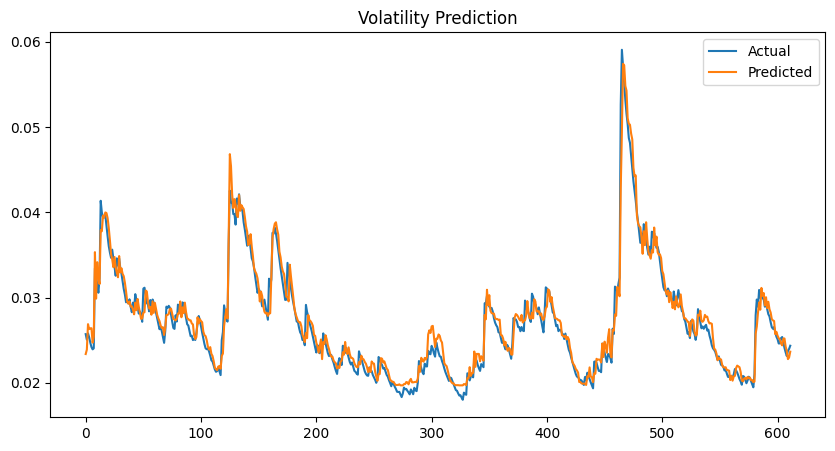

In [34]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.plot(y_test.values, label='Actual')
plt.plot(y_pred, label='Predicted')
plt.legend()
plt.title("Volatility Prediction")
plt.show()